In [3]:
import os
import pandas as pd
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split

In [4]:
load_dotenv(override=True)

file_path = os.getenv('LOAD_CLEAN_PATH')

if not file_path:
    file_path = '/content/cleaned.csv'

In [5]:
try:
    df = pd.read_csv(file_path)
except FileExistsError:
    raise Exception('CRITICAL: File path not found')

In [6]:
df.columns

Index(['Compound', 'TyreLife', 'AirTemp', 'TrackTemp', 'Rainfall',
       'time_delta'],
      dtype='object')

In [7]:
df.head()

,Compound,TyreLife,AirTemp,TrackTemp,Rainfall,time_delta
0,INTERMEDIATE,2.0,16.7,26.2,True,11.414
1,INTERMEDIATE,3.0,16.4,24.8,True,9.624
2,INTERMEDIATE,4.0,16.2,24.6,False,8.666
3,INTERMEDIATE,5.0,16.3,24.3,False,8.279
4,INTERMEDIATE,6.0,16.5,24.1,False,9.395


### Mapping columns `Compund` and `Rainfall` for Regression model

In [8]:
df['Compound'] = df['Compound'].map({'INTERMEDIATE': 0, 'SOFT': 1, 'MEDIUM': 2, 'HARD': 3, 'WET': 4})
df['Rainfall'] = df['Rainfall'].map({True: 1, False: 0})

Text(0.5, 1.0, 'F1 Feature Correlation Matrix')

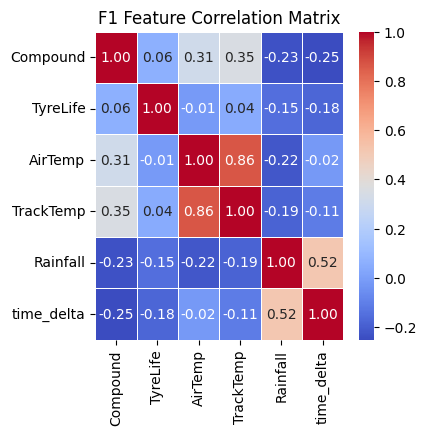

In [11]:
fig, ax = plt.subplots(figsize=(4,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
ax.set_title('F1 Feature Correlation Matrix')

Text(0.5, 1.0, 'Tire Drop-off by Age and Compound')

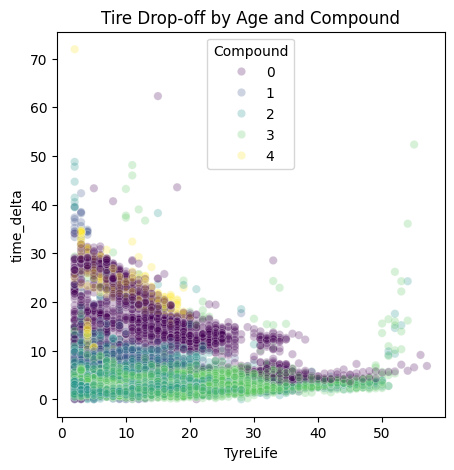

In [13]:
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(data=df, x='TyreLife', y='time_delta', hue='Compound', palette='viridis', alpha=0.25)
ax.set_title('Tire Drop-off by Age and Compound')

Text(0.5, 1.0, 'Rainfall vs Pace')

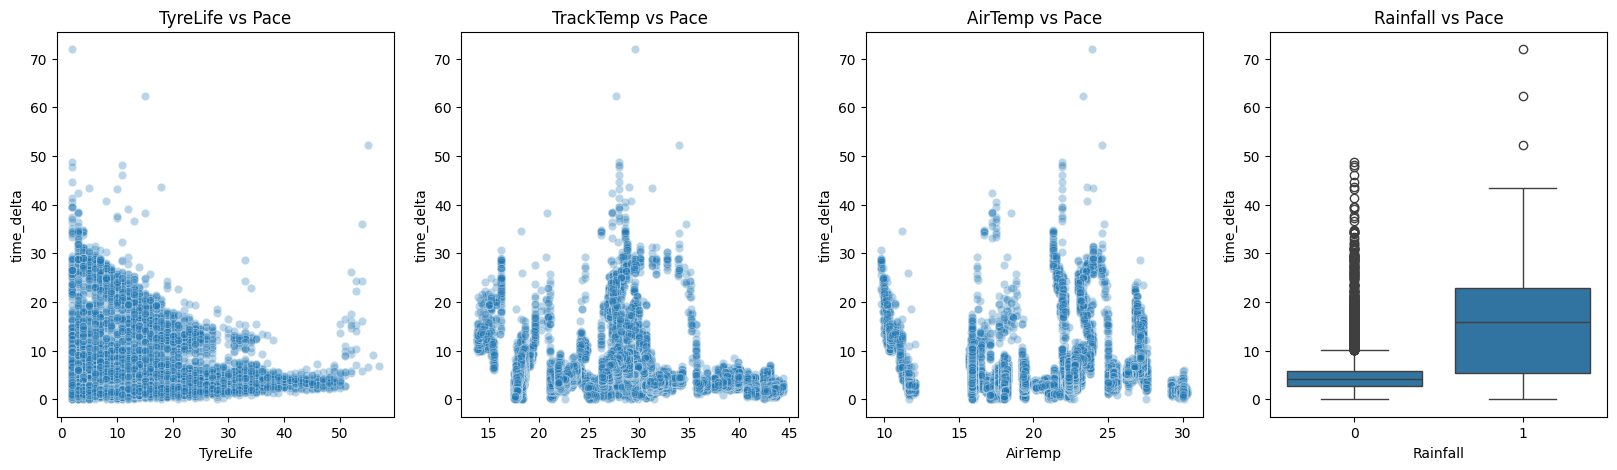

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.scatterplot(data=df, x='TyreLife', y='time_delta', ax=axes[0], alpha=0.3)
axes[0].set_title('TyreLife vs Pace')

sns.scatterplot(data=df, x='TrackTemp', y='time_delta', ax=axes[1], alpha=0.3)
axes[1].set_title('TrackTemp vs Pace')

sns.scatterplot(data=df, x='AirTemp', y='time_delta', ax=axes[2], alpha=0.3)
axes[2].set_title('AirTemp vs Pace')

sns.boxplot(data=df, x='Rainfall', y='time_delta', ax=axes[3])
axes[3].set_title('Rainfall vs Pace')

### Fixing *Compound Compound Encoding quirk*
Due to mapping categorical 'Compound' data to integers, the correlation getting disturbed

In [18]:
df = pd.get_dummies(df, columns=['Compound'])